In [2]:
import importlib

import exp_utils
import plot_utils
import graph_utils
import gen_plot_data

importlib.reload(exp_utils)
importlib.reload(plot_utils)
importlib.reload(graph_utils)
importlib.reload(gen_plot_data)

from exp_utils import process_experiments, process_experiments_nm, prepare_exp_data, OpType, process_experiments_nebula, process_experiments_topo, prepare_relative_exp_data, prepare_nebula_event_throughput_data, prepare_nebula_event_boxplot_summary, \
    prepare_sink_latency_percentile_data, prepare_sink_latency_distribution_data, prepare_latency_throughput_data, prepare_sink_latency_boxplot_summary, prepare_sink_latency_ecdf_data, prepare_metric_boxplot_summary, \
    prepare_throughput_boxplot_summary, prepare_nebula_event_throughput_mean_ci_data, prepare_sink_latency_mean_ci_data, prepare_latency_throughput_data, prepare_sink_latency_summary_data, prepare_grouped_boxplot_summary
from plot_utils import stacked_bar_plot, min_max_operator_plot, boxplot, operator_plot, dag_plot, errorbar_plot, \
    kde_plot, hist_plot, ecdf_plot, event_throughput_line_plot, event_throughput_boxplot, latency_percentile_plot, latency_distribution_plot, latency_throughput_plot, boxplot_from_summary, ecdf_latency_plot, \
        event_throughput_mean_ci_line_plot, latency_mean_ci_line_plot, latency_throughput_plot, latency_throughput_dual_line_plot, repetition_throughput_boxplot
from gen_plot_data import gen_boxplot_summary_data, gen_event_line_ci_data, gen_latency_throughput_data, gen_parallelism_line_ci_data, gen_tput_table_latex, gen_tput_latency_table_data, gen_tput_latency_table_latex
import matplotlib.pyplot as plt
import seaborn as sns
from gen_plot_data import gen_ecdf_data, gen_kde_data, gen_event_line_data, gen_latency_table_data, gen_latency_table_latex, gen_tput_table_data

sns.set_theme()

# plt.style.use('ggplot')

# Intro

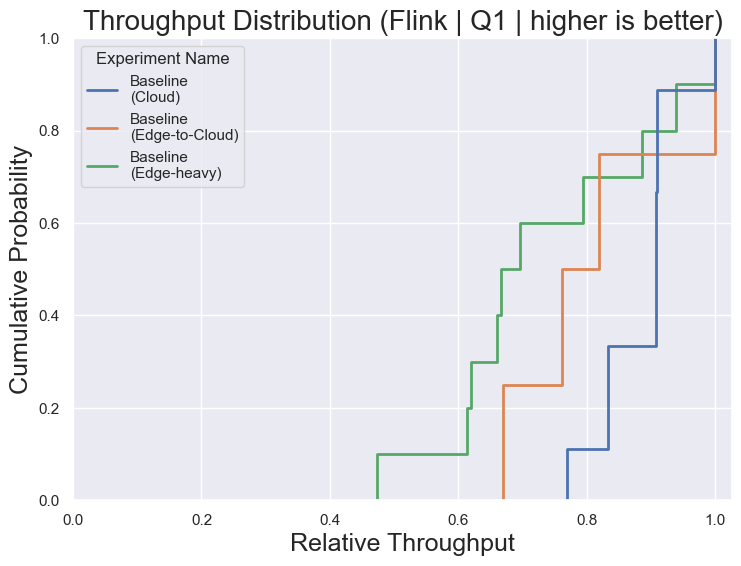

In [244]:
data = process_experiments_topo(path="data_topo", names=["flink_q1_cloud", "flink_q1_e2c", "flink_q1_edge_heavy"])
throughput_data = prepare_relative_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Relative Throughput", title="Throughput Distribution (Flink | Q1 | higher is better)", is_int_axis=False)
# plt.savefig("figs/intro_q1.pdf")
plt.show()
gen_ecdf_data(throughput_data, "intro_q1",output_suffix="paper", x_label="Relative Throughput")

# Requirements

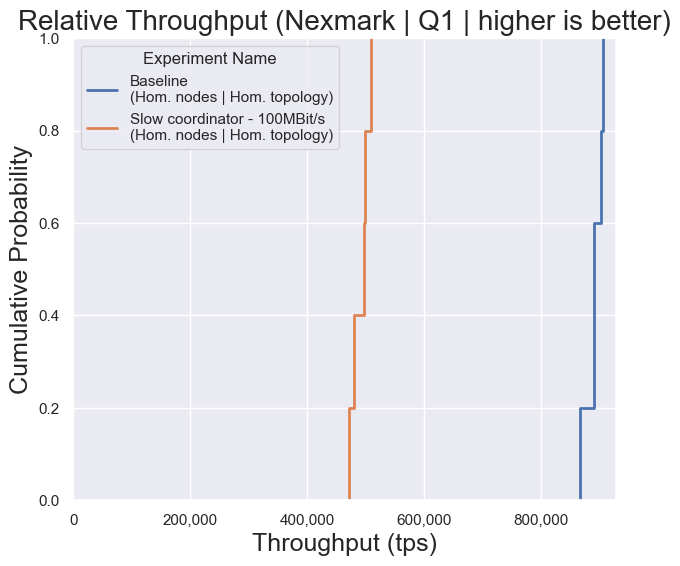

In [245]:
data = process_experiments_nm(names=["base_hom_hom_q1", "slowcoord100mbps_hom_hom_q1"])
throughput_data = prepare_exp_data(data, "throughput", use_source_num_tuples_tps=False)

ecdf_plot(throughput_data, x_name="Throughput (tps)", title="Relative Throughput (Nexmark | Q1 | higher is better)")
# plt.savefig("figs/limitations_slowcoord_ecdf.pdf")
plt.show()
gen_ecdf_data(throughput_data, "limitations_slow_coordinator")

# Evaluation

## Flink

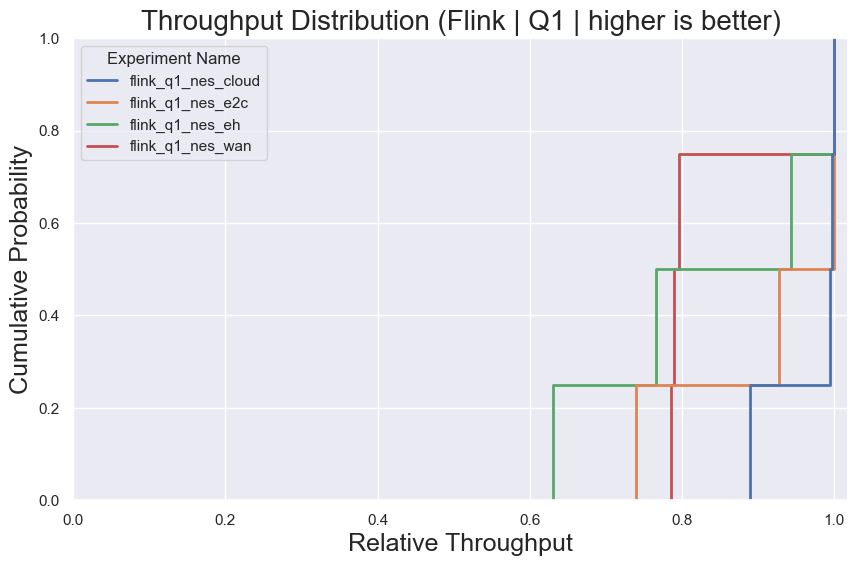

exp_name
flink_q1_nes_cloud    1069993
flink_q1_nes_e2c       358515
flink_q1_nes_eh        281170
flink_q1_nes_wan        66290
Name: abs_value, dtype: int64
                            mean           std    RSD (%)
exp_name                                                 
flink_q1_nes_cloud  1.038192e+06  57239.855208   5.513416
flink_q1_nes_e2c    3.286687e+05  44014.376838  13.391717
flink_q1_nes_eh     2.348752e+05  47443.904897  20.199623
flink_q1_nes_wan    5.586066e+04   6958.184171  12.456323


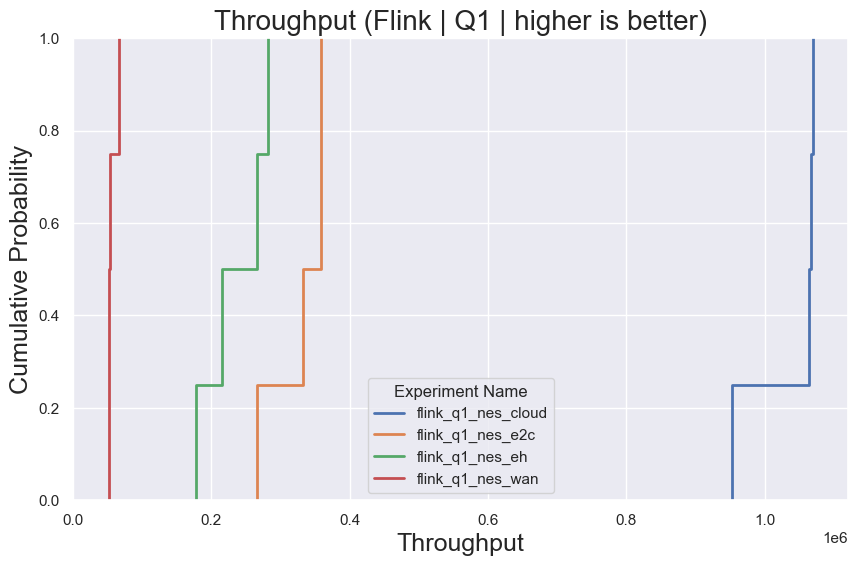

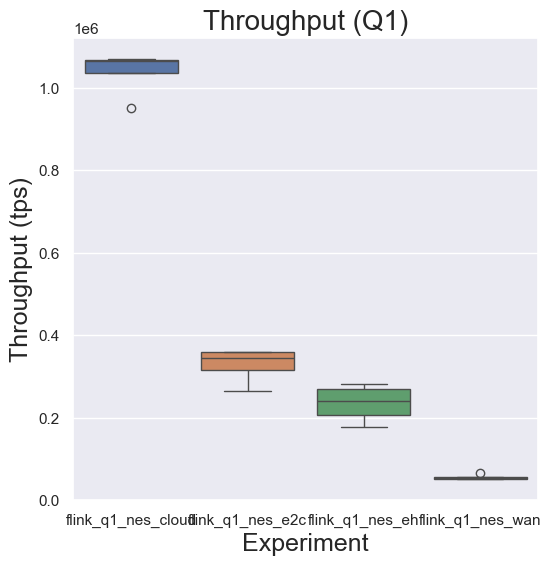

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


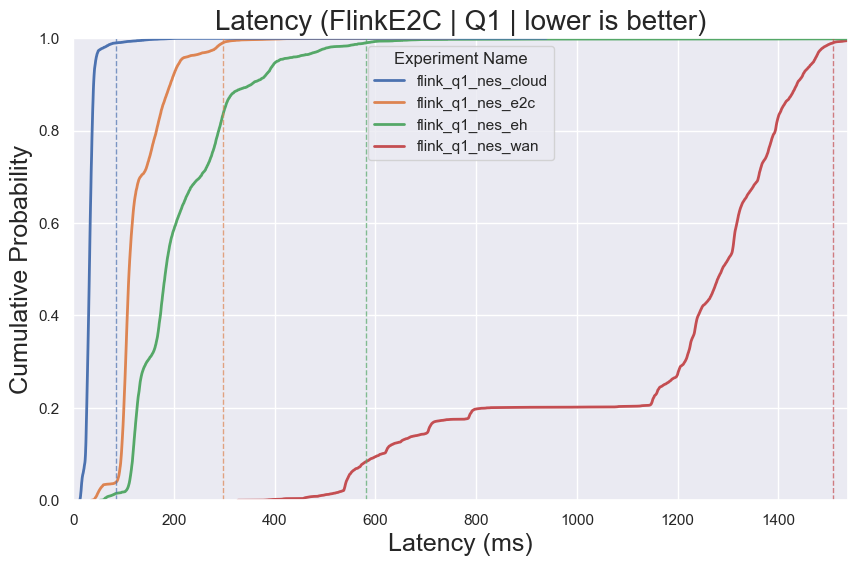

exp_name                
flink_q1_nes_cloud  0.50      32.310384
                    0.90      40.623421
                    0.99      85.016938
flink_q1_nes_e2c    0.50     111.330475
                    0.90     192.819340
                    0.99     297.045040
flink_q1_nes_eh     0.50     184.115645
                    0.90     353.652703
                    0.99     581.214957
flink_q1_nes_wan    0.50    1288.519814
                    0.90    1436.791130
                    0.99    1508.347147
Name: value, dtype: float64


In [ ]:
names=["flink_q1_nes_cloud", "flink_q1_nes_e2c", "flink_q1_nes_eh", "flink_q1_nes_wan"]
data = process_experiments_topo(path="data_new", names=names)
throughput_data = prepare_relative_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Relative Throughput", title="Throughput Distribution (Flink | Q1 | higher is better)", is_int_axis=False)
# plt.savefig("figs/limitations_q1_ecdf.pdf")
plt.show()
gen_ecdf_data(throughput_data, "limitations_rel",output_suffix="paper", x_label="Relative Throughput")
print(throughput_data.groupby("exp_name").max()["abs_value"])

table_data = prepare_exp_data(
    data,
    "throughput",
    exclude_repetitions=(0, 10),
)
stats = table_data.groupby("exp_name")["value"].agg(["mean", "std"])
stats["RSD (%)"] = 100 * stats["std"] / stats["mean"]

print(stats)

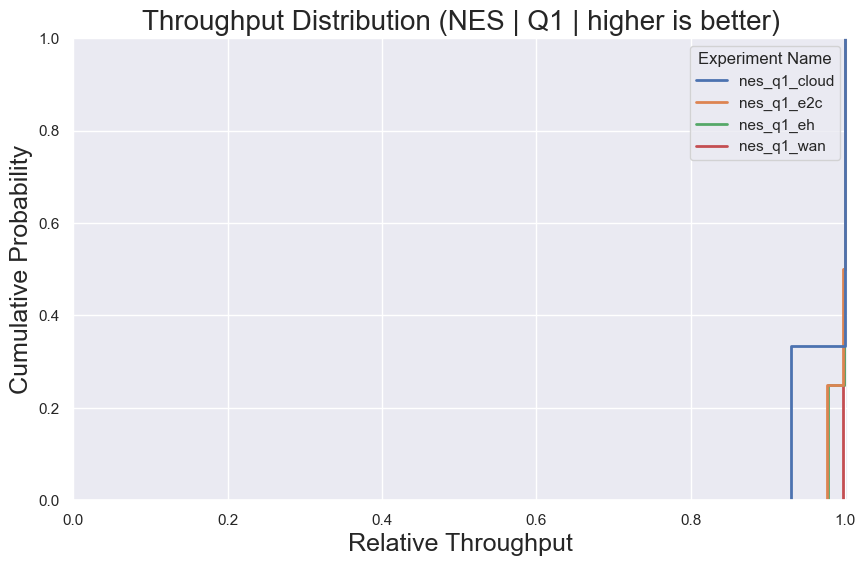

exp_name
nes_q1_cloud    630059
nes_q1_e2c      215636
nes_q1_eh       210748
nes_q1_wan      261828
Name: abs_value, dtype: int64
                       mean           std   RSD (%)
exp_name                                           
nes_q1_cloud  615240.266819  25536.608257  4.150672
nes_q1_e2c    214167.677751   2415.327434  1.127774
nes_q1_eh     209481.022611   2250.317504  1.074235
nes_q1_wan    261529.987742    337.374794  0.129000


In [68]:
data = process_experiments_topo(path="data_new", names=["nes_q1_cloud", "nes_q1_e2c", "nes_q1_eh", "nes_q1_wan"])
throughput_data = prepare_relative_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Relative Throughput", title="Throughput Distribution (NES | Q1 | higher is better)", is_int_axis=False)
# plt.savefig("figs/nes_limitations_q1.pdf")
plt.show()
gen_ecdf_data(throughput_data, "limitations",output_suffix="paper", x_label="Relative Throughput")
print(throughput_data.groupby("exp_name").max()["abs_value"])

table_data = prepare_exp_data(
    data,
    "throughput",
    exclude_repetitions=(0, 10),
)
stats = table_data.groupby("exp_name")["value"].agg(["mean", "std"])
stats["RSD (%)"] = 100 * stats["std"] / stats["mean"]

print(stats)

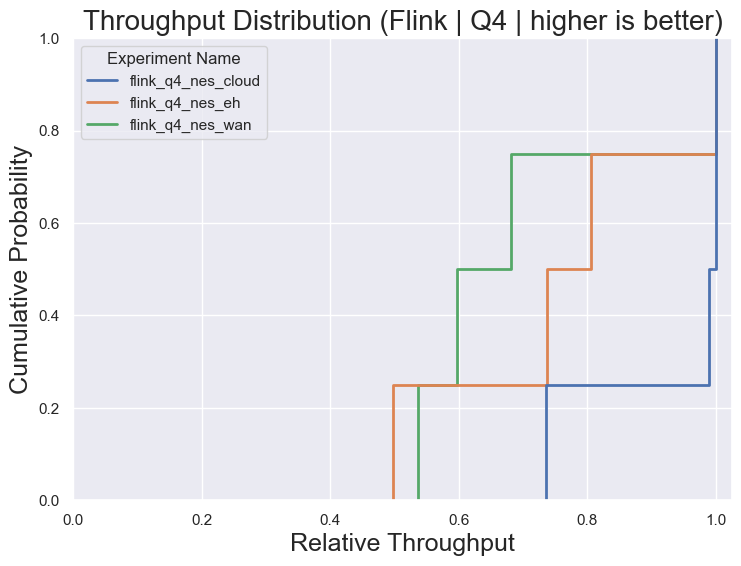

exp_name
flink_q4_nes_cloud    274271
flink_q4_nes_eh        36090
flink_q4_nes_wan       57133
Name: abs_value, dtype: int64
                             mean           std    RSD (%)
exp_name                                                  
flink_q4_nes_cloud  255399.026907  35811.730970  14.021874
flink_q4_nes_eh      27438.116088   7483.719076  27.274901
flink_q4_nes_wan     40213.450266  11784.250302  29.304251


In [62]:
data = process_experiments_topo(path="data_new", names=["flink_q4_nes_cloud", "flink_q4_e2c", "flink_q4_nes_eh", "flink_q4_nes_wan"])
throughput_data = prepare_relative_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Relative Throughput", title="Throughput Distribution (Flink | Q4 | higher is better)", is_int_axis=False)
# plt.savefig("figs/limitations_q4.pdf")
plt.show()
gen_ecdf_data(throughput_data, "limitations",output_suffix="paper", x_label="Relative Throughput")
print(throughput_data.groupby("exp_name").max()["abs_value"])

table_data = prepare_exp_data(
    data,
    "throughput",
    exclude_repetitions=(0, 10),
)
stats = table_data.groupby("exp_name")["value"].agg(["mean", "std"])
stats["RSD (%)"] = 100 * stats["std"] / stats["mean"]

print(stats)

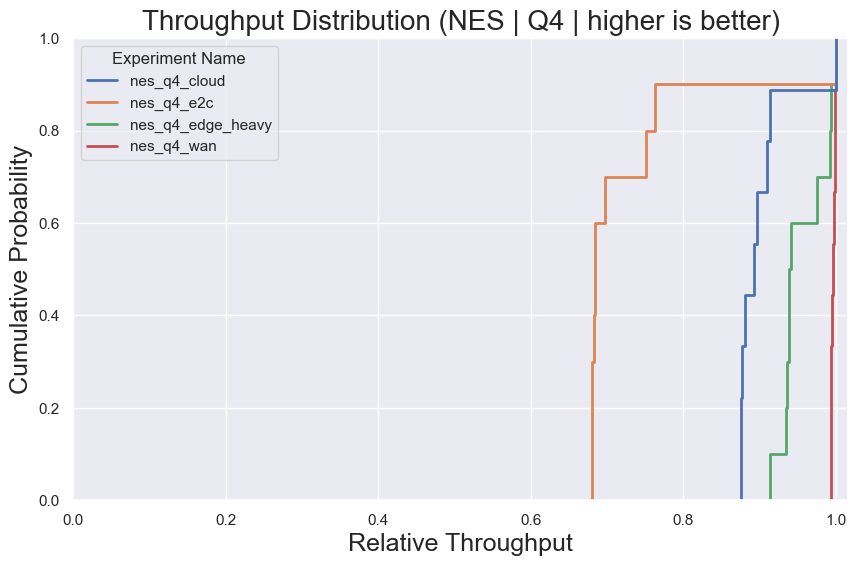

exp_name
nes_q4_cloud         268273
nes_q4_e2c           325874
nes_q4_edge_heavy    238856
nes_q4_wan           224474
Name: abs_value, dtype: int64
                            mean           std    RSD (%)
exp_name                                                 
nes_q4_cloud       242086.940107  10571.559171   4.366844
nes_q4_e2c         239179.580529  34210.270413  14.303174
nes_q4_edge_heavy  228913.605249   7621.074098   3.329236
nes_q4_wan         223694.687718    572.026455   0.255717


In [8]:
data = process_experiments_topo(path="data_topo", names=["nes_q4_cloud", "nes_q4_e2c", "nes_q4_edge_heavy", "nes_q4_wan"])
throughput_data = prepare_relative_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Relative Throughput", title="Throughput Distribution (NES | Q4 | higher is better)", is_int_axis=False)
# plt.savefig("figs/nes_limitations_q4.pdf")
plt.show()
gen_ecdf_data(throughput_data, "limitations",output_suffix="paper", x_label="Relative Throughput")
print(throughput_data.groupby("exp_name").max()["abs_value"])

table_data = prepare_exp_data(
    data,
    "throughput",
    exclude_repetitions=(0, 10),
)
stats = table_data.groupby("exp_name")["value"].agg(["mean", "std"])
stats["RSD (%)"] = 100 * stats["std"] / stats["mean"]

print(stats)

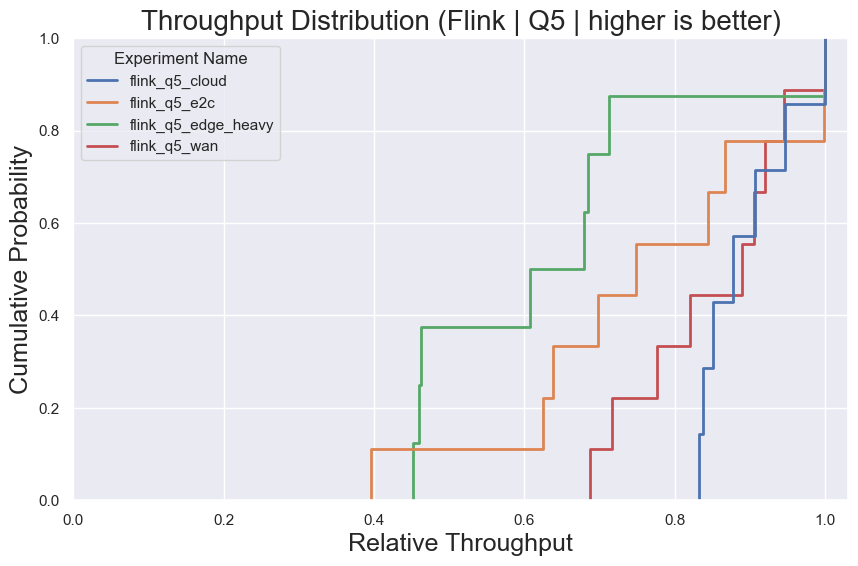

exp_name
flink_q5_cloud         92499
flink_q5_e2c           33282
flink_q5_edge_heavy    31565
flink_q5_wan           14513
Name: abs_value, dtype: int64
                             mean          std    RSD (%)
exp_name                                                 
flink_q5_cloud       82557.510750  5772.214048   6.991749
flink_q5_e2c         24736.014799  6761.398424  27.334227
flink_q5_edge_heavy  19957.166131  5819.764146  29.161275
flink_q5_wan         12349.100508  1553.198568  12.577423


In [6]:
data = process_experiments_topo(path="data_topo", names=["flink_q5_cloud", "flink_q5_e2c", "flink_q5_edge_heavy", "flink_q5_wan"])
throughput_data = prepare_relative_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Relative Throughput", title="Throughput Distribution (Flink | Q5 | higher is better)", is_int_axis=False)
# plt.savefig("figs/limitations_q5.pdf")
plt.show()
gen_ecdf_data(throughput_data, "limitations",output_suffix="paper", x_label="Relative Throughput")
print(throughput_data.groupby("exp_name").max()["abs_value"])

table_data = prepare_exp_data(
    data,
    "throughput",
    exclude_repetitions=(0, 10),
)
stats = table_data.groupby("exp_name")["value"].agg(["mean", "std"])
stats["RSD (%)"] = 100 * stats["std"] / stats["mean"]

print(stats)

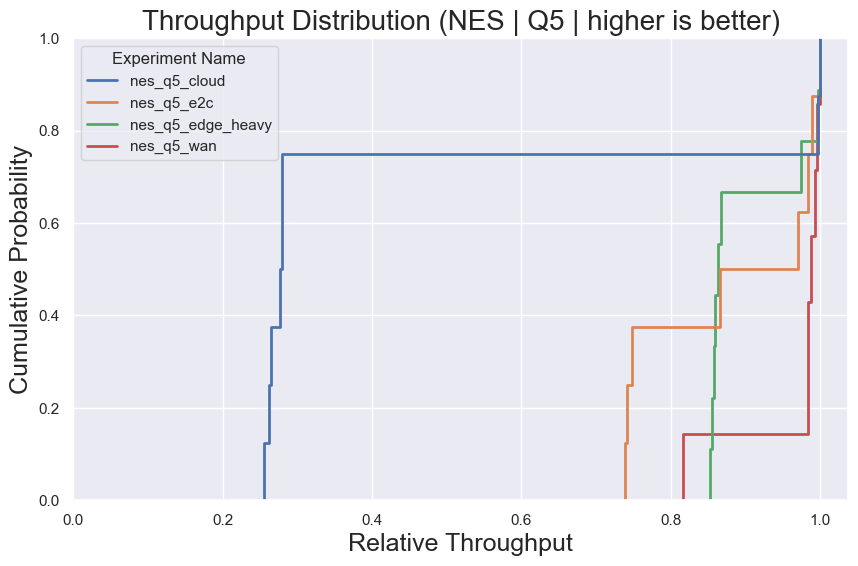

exp_name
nes_q5_cloud         835694
nes_q5_e2c           285903
nes_q5_edge_heavy    236214
nes_q5_wan           265811
Name: abs_value, dtype: int64
                            mean            std    RSD (%)
exp_name                                                  
nes_q5_cloud       377799.184090  282052.929695  74.656839
nes_q5_e2c         251515.093714   34567.602747  13.743749
nes_q5_edge_heavy  214455.419145   16254.380666   7.579375
nes_q5_wan         256627.616963   17613.047225   6.863270


In [7]:
data = process_experiments_topo(path="data_topo", names=["nes_q5_cloud", "nes_q5_e2c", "nes_q5_edge_heavy", "nes_q5_wan"])
throughput_data = prepare_relative_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Relative Throughput", title="Throughput Distribution (NES | Q5 | higher is better)", is_int_axis=False)
# plt.savefig("figs/nes_limitations_q5.pdf")
plt.show()
gen_ecdf_data(throughput_data, "limitations",output_suffix="paper", x_label="Relative Throughput")
print(throughput_data.groupby("exp_name").max()["abs_value"])

table_data = prepare_exp_data(
    data,
    "throughput",
    exclude_repetitions=(0, 10),
)
stats = table_data.groupby("exp_name")["value"].agg(["mean", "std"])
stats["RSD (%)"] = 100 * stats["std"] / stats["mean"]

print(stats)

# Absolute

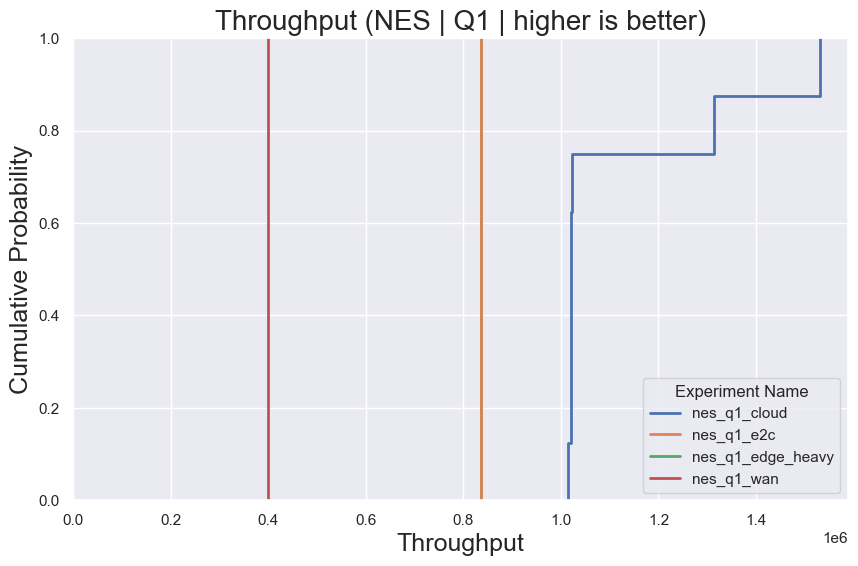

In [17]:
data = process_experiments_topo(path="data_topo", names=["nes_q1_cloud", "nes_q1_e2c", "nes_q1_edge_heavy", "nes_q1_wan"])
throughput_data = prepare_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Throughput", title="Throughput (NES | Q1 | higher is better)", is_int_axis=False)
# plt.savefig("figs/placement_q1_abs_ecdf.pdf")
plt.show()
gen_ecdf_data(throughput_data, "placement_abs",output_suffix="paper", x_label="Throughput (tps)")

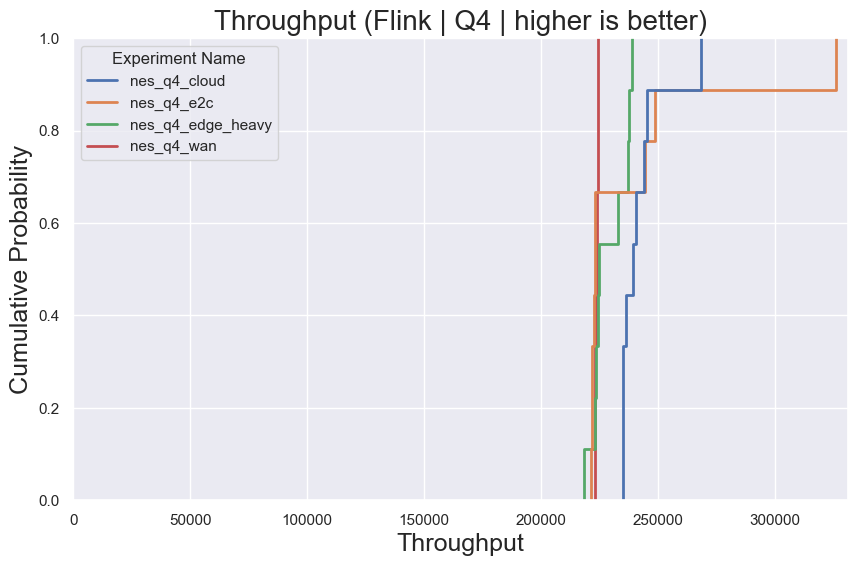

In [19]:
data = process_experiments_topo(path="data_topo", names=["nes_q4_cloud", "nes_q4_e2c", "nes_q4_edge_heavy", "nes_q4_wan"])
throughput_data = prepare_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Throughput", title="Throughput (Flink | Q4 | higher is better)", is_int_axis=False)
# plt.savefig("figs/placement_q4_abs_ecdf.pdf")
plt.show()
gen_ecdf_data(throughput_data, "placement_abs",output_suffix="paper", x_label="Throughput (tps)")

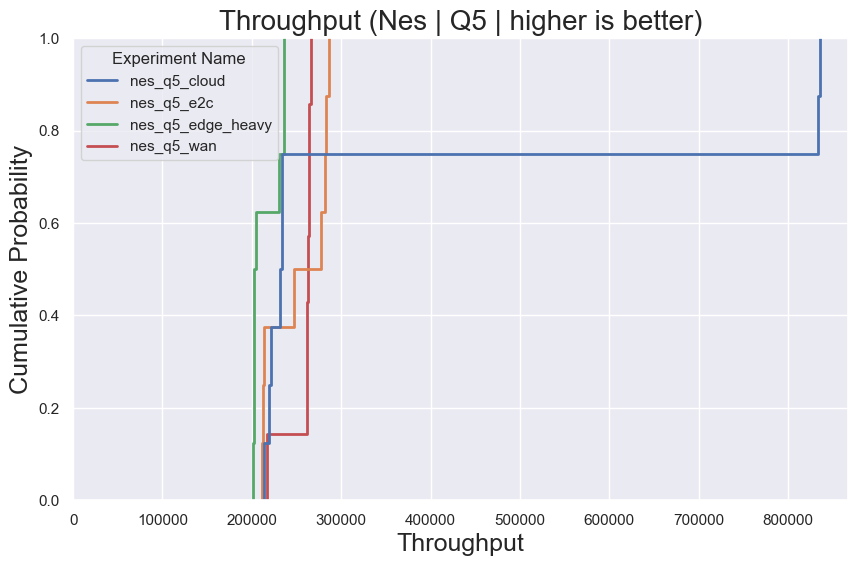

In [23]:
data = process_experiments_topo(path="data_topo", names=["nes_q5_cloud", "nes_q5_e2c", "nes_q5_edge_heavy", "nes_q5_wan"])
throughput_data = prepare_exp_data(data, "throughput")

ecdf_plot(throughput_data, x_name="Throughput", title="Throughput (Nes | Q5 | higher is better)", is_int_axis=False)
# plt.savefig("figs/placement_q5_abs_ecdf.pdf")
plt.show()
gen_ecdf_data(throughput_data, "placement_abs",output_suffix="paper", x_label="Throughput (tps)")

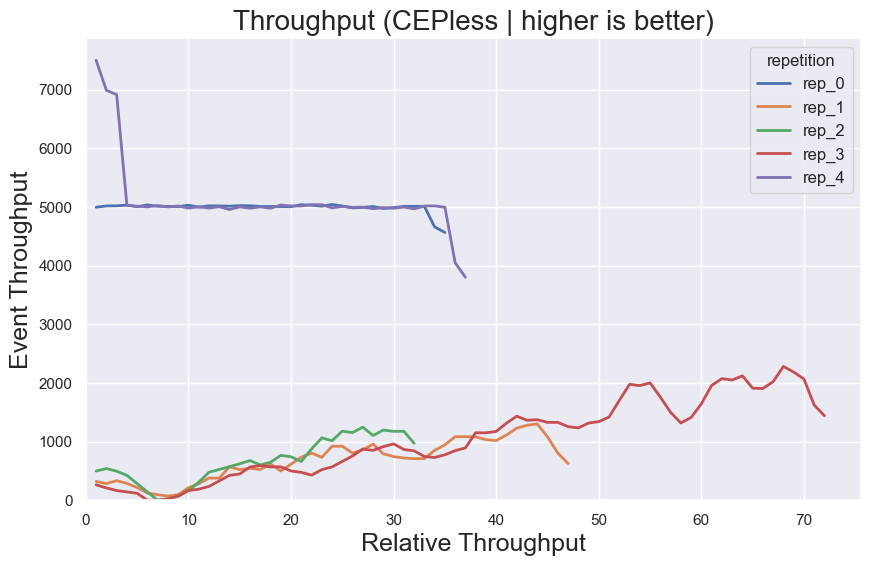

In [281]:
data = process_experiments_nebula(path="data_paper/flink_cepless", names=["het_het"])
event_data = prepare_nebula_event_throughput_data(data, smooth_window=5)

event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (CEPless | higher is better)")
# plt.savefig("figs/flink_cepless.pdf")
plt.show()
boxplot_stats = prepare_nebula_event_boxplot_summary(data)
boxplot_stats.to_csv("plot_data_paper/flink_cepless_boxplot.csv", index=False)
event_df = prepare_nebula_event_throughput_data(data, smooth_window=5)
line_meta = gen_event_line_data(event_df, "flink_cepless_line", output_suffix="paper", use_smoothed=True)

## External Runtime

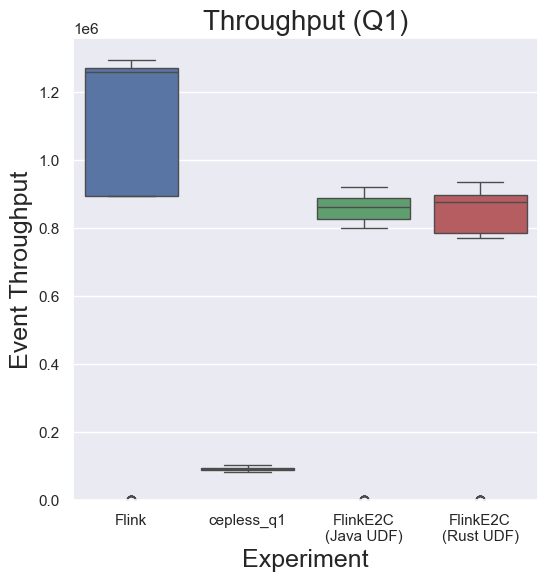

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


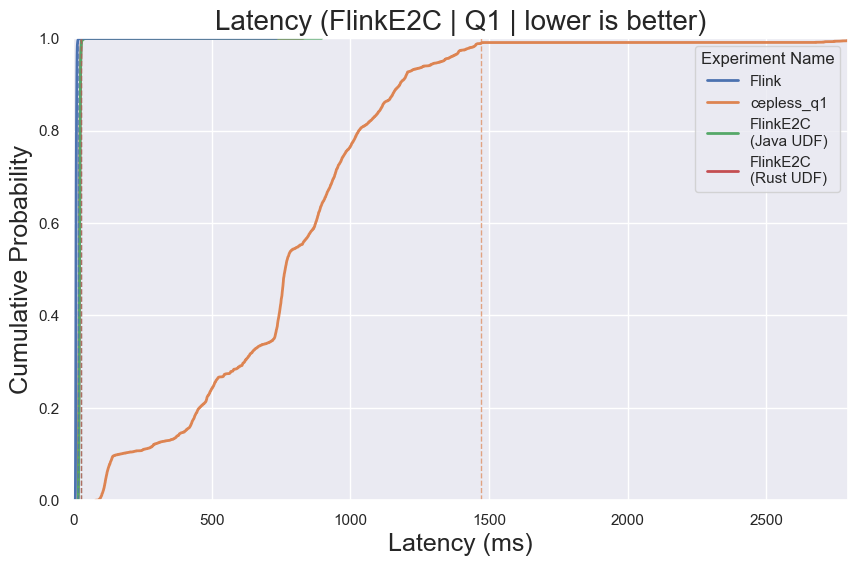

('plot_data_paper/dyn_q1_tput_boxplot.csv',
 'plot_data_paper/dyn_q1_tput_boxplot_outliers.csv')

In [2]:
names = ["flink_q1", "cepless_q1", "flinke2c_judf_q1", "flinke2c_rudf_q1"]
data = process_experiments_nebula(path="data_with_det/runtime", names=names)
event_data = prepare_nebula_event_throughput_data(data)
ecdf_lat_df = prepare_sink_latency_ecdf_data("data_with_det/runtime", names=names, unit="ms", relative=False)
tput_boxplot_data = prepare_throughput_boxplot_summary("data_with_det/runtime", names=names)

# event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1)", hue="exp_name", legend=False)
plt.savefig("figs/flinke2c_dyn.pdf")
plt.show()

ecdf_latency_plot(
    ecdf_lat_df,
    title="Latency (FlinkE2C | Q1 | lower is better)",
    x_name="Latency (ms)",
    percentiles=(99,),
    clip_percentile=99.5,
)
# plt.savefig("figs/dyn_q1_lat_ecdf.pdf")
plt.show()
gen_ecdf_data(
    ecdf_lat_df,
    "dyn_lat",
    output_suffix="paper",
    x_label="Latency (ms)",
    max_points=400,
    uniform=True,
    keep_quantiles=[99],
    clip_percentile=99.5,
    marker_percentiles=[99],
)

# boxplot_from_summary(
#     lat_df,
#     y_name="Latency (ms)",
#     title="End-to-end Latency (Q1)",
#     x="exp_name",
#     x_name="Experiment",
# )
# plt.show()
gen_boxplot_summary_data(
    tput_boxplot_data,
    "dyn_q1_tput",
    output_suffix="paper",
    x_col="exp_name",
    include_outliers=True,
)

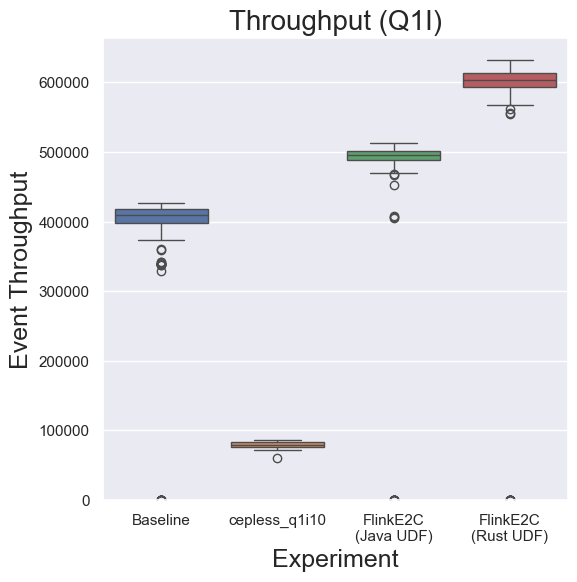

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


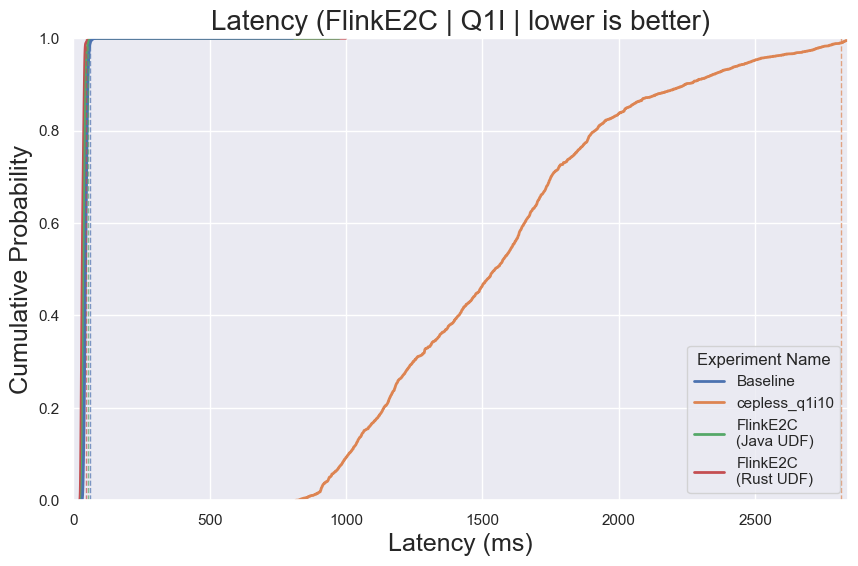

('plot_data_paper/dyn_q1i10_tput_boxplot.csv',
 'plot_data_paper/dyn_q1i10_tput_boxplot_outliers.csv')

In [3]:
names = ["flink_q1i10", "cepless_q1i10","flinke2c_judf_q1i10", "flinke2c_rudf_q1i10"]
data = process_experiments_nebula(path="data_with_det/runtime", names=names)
event_data = prepare_nebula_event_throughput_data(data)
ecdf_lat_df = prepare_sink_latency_ecdf_data("data_with_det/runtime", names=names, unit="ms", relative=False)
tput_boxplot_data = prepare_throughput_boxplot_summary("data_with_det/runtime", names=names)

# event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1I)", hue="exp_name", legend=False)
# plt.savefig("figs/flinke2c_dyn.pdf")
plt.show()

ecdf_latency_plot(
    ecdf_lat_df,
    title="Latency (FlinkE2C | Q1I | lower is better)",
    x_name="Latency (ms)",
    percentiles=(99,),
    clip_percentile=99.5,
)
# plt.savefig("figs/dyn_q1i10_lat_ecdf.pdf")
plt.show()
gen_ecdf_data(
    ecdf_lat_df,
    "dyn_lat",
    output_suffix="paper",
    x_label="Latency (ms)",
    max_points=400,
    uniform=True,
    keep_quantiles=[99],
    clip_percentile=99.5,
    marker_percentiles=[99],
)

# boxplot_from_summary(
#     lat_df,
#     y_name="Latency (ms)",
#     title="End-to-end Latency (Q1)",
#     x="exp_name",
#     x_name="Experiment",
# )
# plt.show()
gen_boxplot_summary_data(
    tput_boxplot_data,
    "dyn_q1i10_tput",
    output_suffix="paper",
    x_col="exp_name",
    include_outliers=True,
)

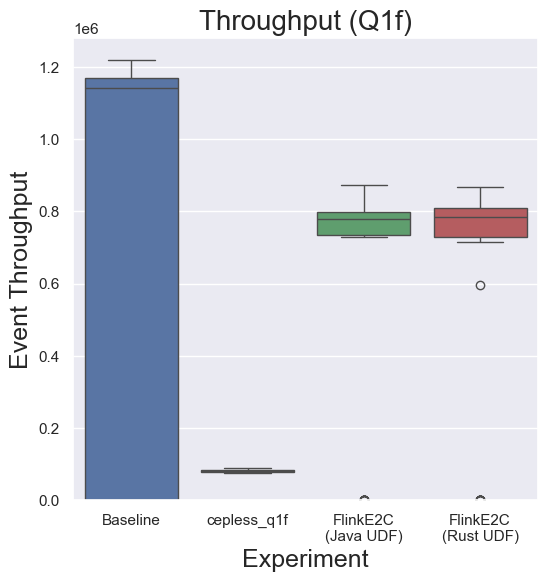

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


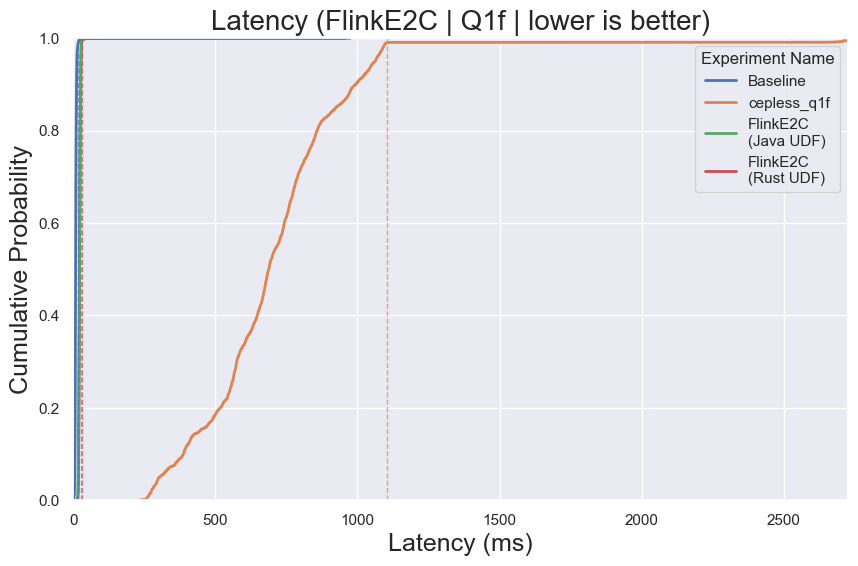

('plot_data_paper/dyn_q1f_tput_boxplot.csv',
 'plot_data_paper/dyn_q1f_tput_boxplot_outliers.csv')

In [4]:
names = ["flink_q1f", "cepless_q1f","flinke2c_judf_q1f", "flinke2c_rudf_q1f"]
data = process_experiments_nebula(path="data_with_det/runtime", names=names)
event_data = prepare_nebula_event_throughput_data(data)
ecdf_lat_df = prepare_sink_latency_ecdf_data("data_with_det/runtime", names=names, unit="ms", relative=False)
tput_boxplot_data = prepare_throughput_boxplot_summary("data_with_det/runtime", names=names)

# event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1f)", hue="exp_name", legend=False)
# plt.savefig("figs/flinke2c_dyn.pdf")
plt.show()

ecdf_latency_plot(
    ecdf_lat_df,
    title="Latency (FlinkE2C | Q1f | lower is better)",
    x_name="Latency (ms)",
    percentiles=(99,),
    clip_percentile=99.5,
)
# plt.savefig("figs/dyn_q1f_lat_ecdf.pdf")
plt.show()
gen_ecdf_data(
    ecdf_lat_df,
    "dyn_lat",
    output_suffix="paper",
    x_label="Latency (ms)",
    max_points=400,
    uniform=True,
    keep_quantiles=[99],
    clip_percentile=99.5,
    marker_percentiles=[99],
)

# boxplot_from_summary(
#     lat_df,
#     y_name="Latency (ms)",
#     title="End-to-end Latency (Q1)",
#     x="exp_name",
#     x_name="Experiment",
# )
# plt.show()
gen_boxplot_summary_data(
    tput_boxplot_data,
    "dyn_q1f_tput",
    output_suffix="paper",
    x_col="exp_name",
    include_outliers=True,
)

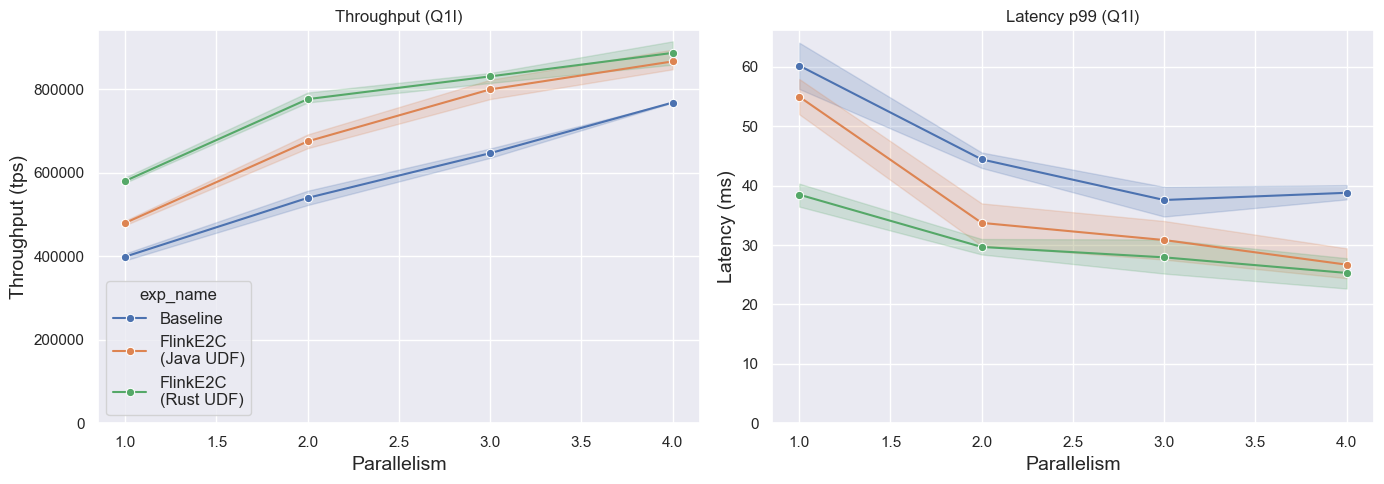

[{'path': 'plot_data_paper/latency_parallelism_flink_q1i10.csv',
  'exp_name': 'Baseline',
  'label_tex': 'Baseline'},
 {'path': 'plot_data_paper/latency_parallelism_flinke2c_judf_q1i10.csv',
  'exp_name': 'FlinkE2C\n(Java UDF)',
  'label_tex': 'FlinkE2C\n(Java UDF)'},
 {'path': 'plot_data_paper/latency_parallelism_flinke2c_rudf_q1i10.csv',
  'exp_name': 'FlinkE2C\n(Rust UDF)',
  'label_tex': 'FlinkE2C\n(Rust UDF)'}]

In [25]:
names = ["flink_q1i10", "flinke2c_rudf_q1i10", "flinke2c_judf_q1i10"]

lt_df = prepare_latency_throughput_data(
    base_path="data_with_det/runtime/parallel",
    names=names,
    latency_percentile=99,
    exclude_repetitions=(0,),
    unit="ms",
    per_test=True,
)

fig, axs = latency_throughput_dual_line_plot(
    lt_df,
    throughput_title="Throughput (Q1I)",
    latency_title="Latency p99 (Q1I)",
    x="parallelism",
    x_name="Parallelism",
    throughput_name="Throughput (tps)",
    latency_name="Latency (ms)",
    hue="exp_name",
    throughput_ci=95,
    latency_ci=95,
)

plt.tight_layout()
plt.show()

gen_parallelism_line_ci_data(
    lt_df,
    "throughput_parallelism",
    output_suffix="paper",
    x_col="parallelism",
    y_col="throughput",
    ci=0.95,
)

gen_parallelism_line_ci_data(
    lt_df,
    "latency_parallelism",
    output_suffix="paper",
    x_col="parallelism",
    y_col="latency",
    ci=0.95,
)

## GPU

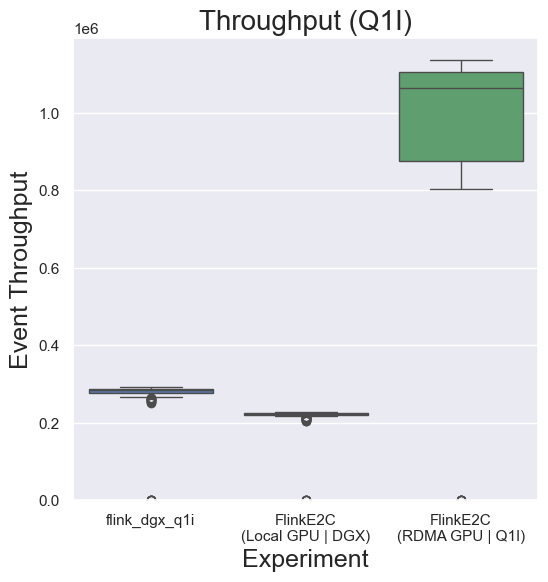

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


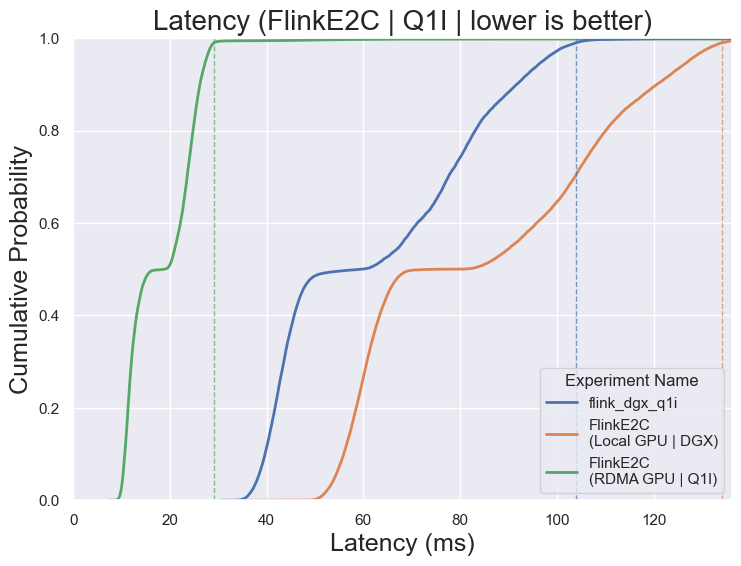

('plot_data_paper/dyn_q1i10_tput_boxplot.csv',
 'plot_data_paper/dyn_q1i10_tput_boxplot_outliers.csv')

In [ ]:
names = ["flink_dgx_q1i", "flinke2c_local_gpu_q1i", "flinke2c_gpu_q1i"]
data = process_experiments_nebula(path="data", names=names)
event_data = prepare_nebula_event_throughput_data(data)
ecdf_lat_df = prepare_sink_latency_ecdf_data("data", names=names, unit="ms", relative=False)
tput_boxplot_data = prepare_throughput_boxplot_summary("data", names=names)

# event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1I)", hue="exp_name", legend=False)
# plt.savefig("figs/flinke2c_dyn.pdf")
plt.show()

ecdf_latency_plot(
    ecdf_lat_df,
    title="Latency (FlinkE2C | Q1I | lower is better)",
    x_name="Latency (ms)",
    percentiles=(99,),
    clip_percentile=99.5,
)
# plt.savefig("figs/dyn_q1i10_lat_ecdf.pdf")
plt.show()
gen_ecdf_data(
    ecdf_lat_df,
    "dyn_lat",
    output_suffix="paper",
    x_label="Latency (ms)",
    max_points=400,
    uniform=True,
    keep_quantiles=[99],
    clip_percentile=99.5,
    marker_percentiles=[99],
)

# boxplot_from_summary(
#     lat_df,
#     y_name="Latency (ms)",
#     title="End-to-end Latency (Q1)",
#     x="exp_name",
#     x_name="Experiment",
# )
# plt.show()
gen_boxplot_summary_data(
    tput_boxplot_data,
    "dyn_q1i10_tput",
    output_suffix="paper",
    x_col="exp_name",
    include_outliers=True,
)flinke2c_local_gpu_q1

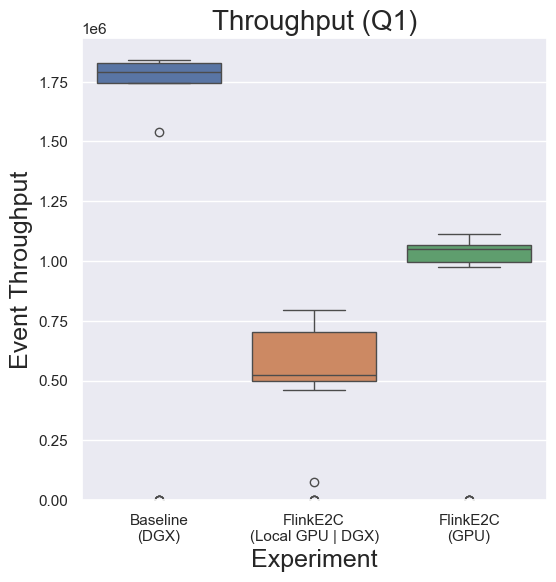

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


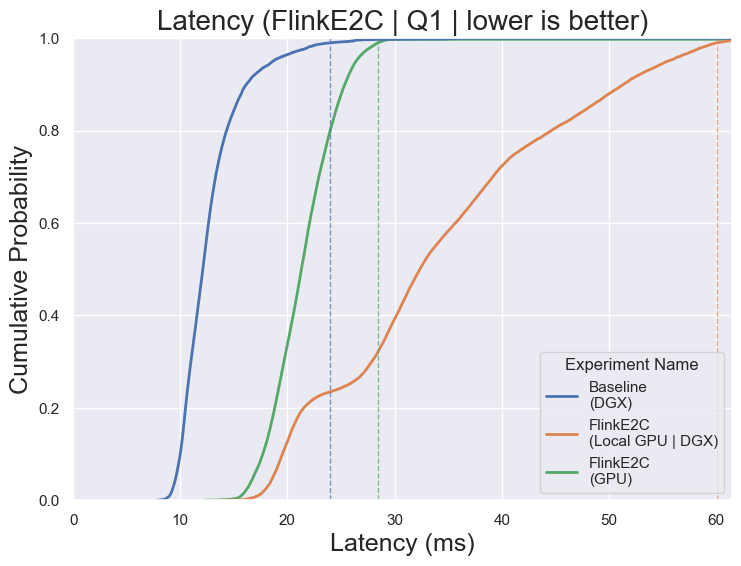

('plot_data_paper/dyn_q1_tput_boxplot.csv',
 'plot_data_paper/dyn_q1_tput_boxplot_outliers.csv')

In [2]:
names = ["flink_dgx_q1", "flinke2c_local_gpu_q1", "flinke2c_gpu_q1"]
data = process_experiments_nebula(path="data", names=names)
event_data = prepare_nebula_event_throughput_data(data)
ecdf_lat_df = prepare_sink_latency_ecdf_data("data", names=names, unit="ms", relative=False)
tput_boxplot_data = prepare_throughput_boxplot_summary("data", names=names)

# event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1)", hue="exp_name", legend=False)
# plt.savefig("figs/flinke2c_dyn.pdf")
plt.show()

ecdf_latency_plot(
    ecdf_lat_df,
    title="Latency (FlinkE2C | Q1 | lower is better)",
    x_name="Latency (ms)",
    percentiles=(99,),
    clip_percentile=99.5,
)
# plt.savefig("figs/dyn_q1i10_lat_ecdf.pdf")
plt.show()
gen_ecdf_data(
    ecdf_lat_df,
    "dyn_lat",
    output_suffix="paper",
    x_label="Latency (ms)",
    max_points=400,
    uniform=True,
    keep_quantiles=[99],
    clip_percentile=99.5,
    marker_percentiles=[99],
)

# boxplot_from_summary(
#     lat_df,
#     y_name="Latency (ms)",
#     title="End-to-end Latency (Q1)",
#     x="exp_name",
#     x_name="Experiment",
# )
# plt.show()
gen_boxplot_summary_data(
    tput_boxplot_data,
    "dyn_q1_tput",
    output_suffix="paper",
    x_col="exp_name",
    include_outliers=True,
)

In [ ]:
# names = ["flinke2c_rudf_q1i10/1", "flink_q1i10/1", "flinke2c_rudf_q1i10/2","flink_q1i10/2", "flinke2c_rudf_q1i10/3", "flink_q1i10/3", "flinke2c_rudf_q1i10/4", "flink_q1i10/4"]
# data = process_experiments_nebula(path="data/parallel", names=names)
# event_data = prepare_nebula_event_throughput_data(data)

# # event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
# event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1I)", hue="exp_name", legend=False)

# ecdf_lat_df = prepare_sink_latency_ecdf_data("data/parallel", names=names, max_points=20000, unit="ms", relative=False)
# ecdf_latency_plot(
#     ecdf_lat_df,
#     title="Latency (FlinkE2C | Q1I | lower is better)",
#     x_name="Latency (ms)",
#     percentiles=(99,),
#     clip_percentile=99.5,
# )

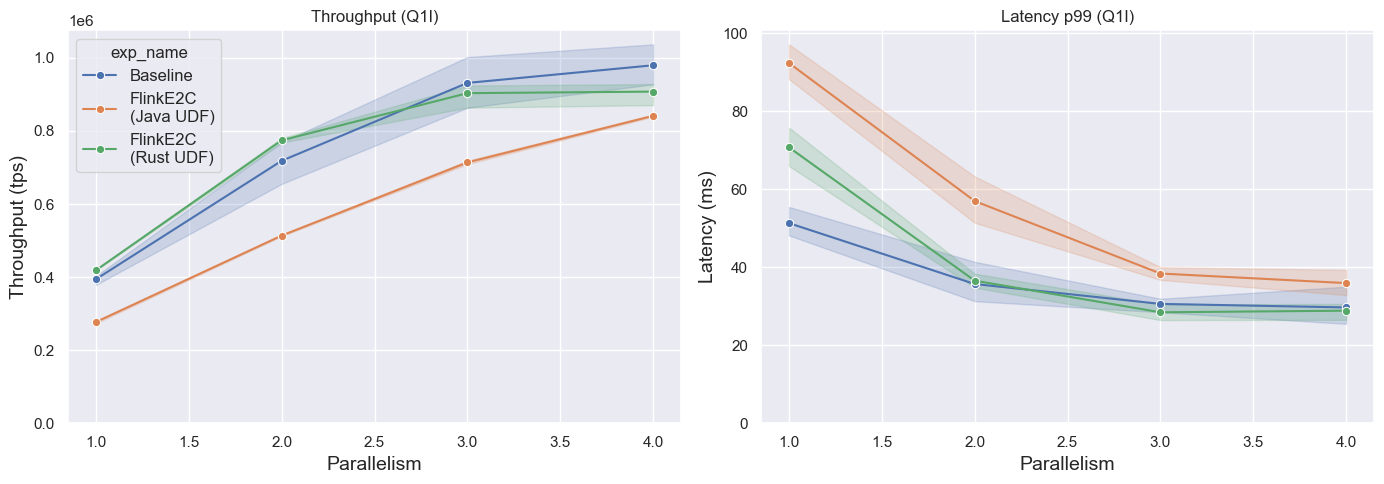

[{'path': 'plot_data_paper/latency_parallelism_flink_q1i10.csv',
  'exp_name': 'Baseline',
  'label_tex': 'Baseline'},
 {'path': 'plot_data_paper/latency_parallelism_flinke2c_judf_q1i10.csv',
  'exp_name': 'FlinkE2C\n(Java UDF)',
  'label_tex': 'FlinkE2C\n(Java UDF)'},
 {'path': 'plot_data_paper/latency_parallelism_flinke2c_rudf_q1i10.csv',
  'exp_name': 'FlinkE2C\n(Rust UDF)',
  'label_tex': 'FlinkE2C\n(Rust UDF)'}]

In [ ]:
names = ["flink_q1i10", "flinke2c_rudf_q1i10", "flinke2c_judf_q1i10"]

lt_df = prepare_latency_throughput_data(
    base_path="data/parallel",
    names=names,
    latency_percentile=99,
    exclude_repetitions=(0,),
    unit="ms",
    per_test=True,
)

# latency_throughput_plot(
#     lt_df,
#     title="Latency vs Throughput (Q1I)",
#     x_name="Throughput (tps)",
#     y_name="Latency (ms)",
# )

# gen_latency_throughput_data(
#     lt_df,
#     "q1i_latency_throughput",
#     output_suffix="paper",
# )

fig, axs = latency_throughput_dual_line_plot(
    lt_df,
    throughput_title="Throughput (Q1I)",
    latency_title="Latency p99 (Q1I)",
    x="parallelism",
    x_name="Parallelism",
    throughput_name="Throughput (tps)",
    latency_name="Latency (ms)",
    hue="exp_name",
    throughput_ci=95,
    latency_ci=95,
)

plt.tight_layout()
plt.show()

gen_parallelism_line_ci_data(
    lt_df,
    "throughput_parallelism",
    output_suffix="paper",
    x_col="parallelism",
    y_col="throughput",
    ci=0.95,
)

gen_parallelism_line_ci_data(
    lt_df,
    "latency_parallelism",
    output_suffix="paper",
    x_col="parallelism",
    y_col="latency",
    ci=0.95,
)

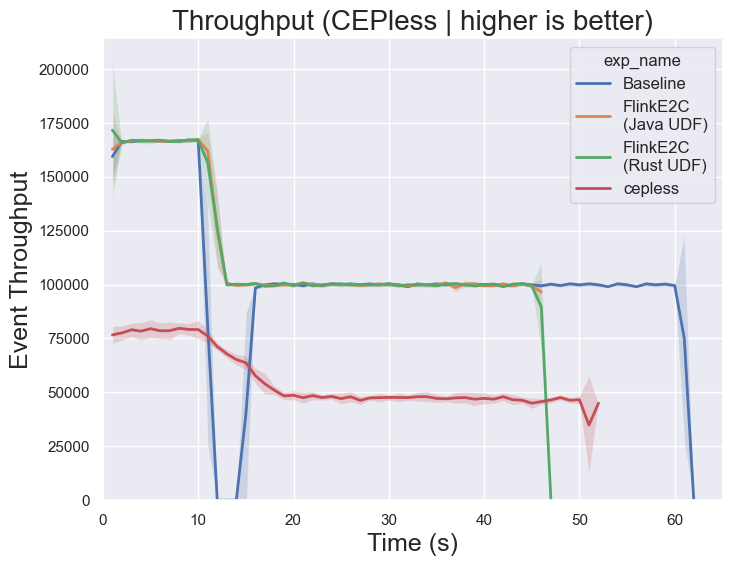

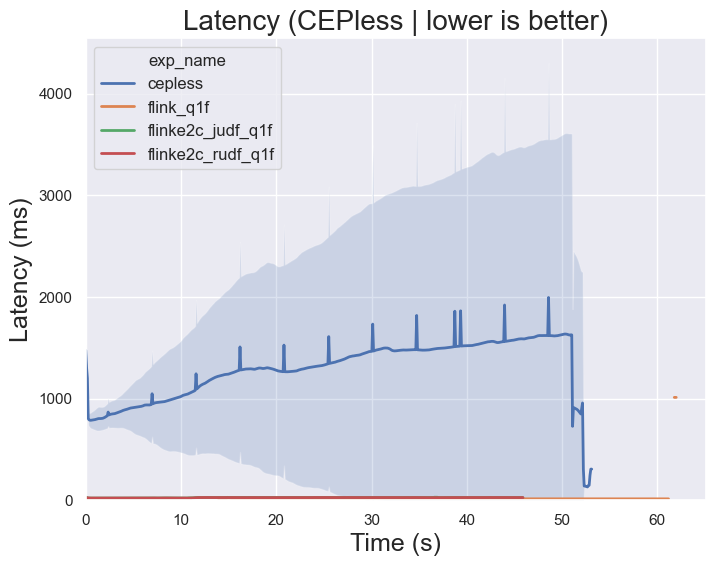

[{'path': 'plot_data_paper/filter_update_latency_line_ci_cepless.csv',
  'exp_name': 'cepless',
  'label_tex': 'cepless',
  'marker_path': None},
 {'path': 'plot_data_paper/filter_update_latency_line_ci_flink_q1f.csv',
  'exp_name': 'flink_q1f',
  'label_tex': 'flink\\\\_q1f',
  'marker_path': None},
 {'path': 'plot_data_paper/filter_update_latency_line_ci_flinke2c_judf_q1f.csv',
  'exp_name': 'flinke2c_judf_q1f',
  'label_tex': 'flinke2c\\\\_judf\\\\_q1f',
  'marker_path': None},
 {'path': 'plot_data_paper/filter_update_latency_line_ci_flinke2c_rudf_q1f.csv',
  'exp_name': 'flinke2c_rudf_q1f',
  'label_tex': 'flinke2c\\\\_rudf\\\\_q1f',
  'marker_path': None}]

In [4]:
data = process_experiments_nebula(path="data/update", names=["flink_q1f", "flinke2c_judf_q1f", "flinke2c_rudf_q1f", "cepless"])
event_data = prepare_nebula_event_throughput_mean_ci_data(data, ci=0.95)

event_throughput_mean_ci_line_plot(
    event_data,
    x_name="Time (s)",
    title="Throughput (CEPless | higher is better)",
    hue="exp_name",
)
# plt.savefig("figs/filter_update.pdf")
plt.show()
gen_event_line_ci_data(
    event_data,
    "filter_update_line_ci",
    output_suffix="paper",
)

latency_data = prepare_sink_latency_mean_ci_data("data/update", names=["flink_q1f", "flinke2c_judf_q1f", "flinke2c_rudf_q1f", "cepless"], unit="ms", ci=0.95, exclude_repetitions=(0,), max_points=600, smooth_window=5, gap_fill="nan")
latency_mean_ci_line_plot(
    latency_data,
    x_name="Time (s)",
    title="Latency (CEPless | lower is better)",
    hue="exp_name",
)
# plt.savefig("figs/filter_update_latency_ci.pdf")
plt.show()
gen_event_line_ci_data(
    latency_data,
    "filter_update_latency_line_ci",
    output_suffix="paper",
)

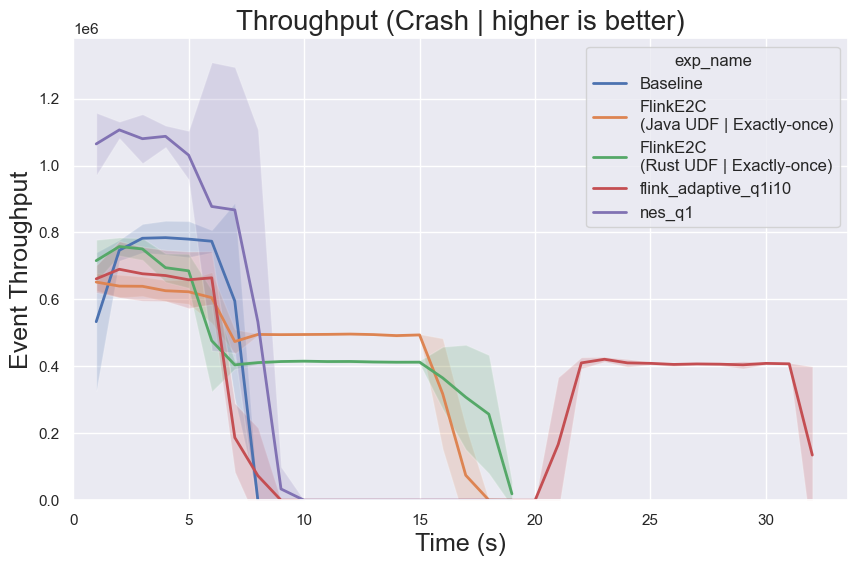

[{'path': 'plot_data_paper/crash_line_ci_ack_flink_q1i10.csv',
  'exp_name': 'Baseline',
  'label_tex': 'Baseline',
  'marker_path': 'plot_data_paper/crash_line_ci_ack_flink_q1i10_last_x.csv'},
 {'path': 'plot_data_paper/crash_line_ci_ack_flinke2c_judf_q1i10_ack.csv',
  'exp_name': 'FlinkE2C\n(Java UDF | Exactly-once)',
  'label_tex': 'FlinkE2C\\\\(Java UDF \\\\textbar{} Exactly-once)',
  'marker_path': None},
 {'path': 'plot_data_paper/crash_line_ci_ack_flinke2c_rudf_q1i10_ack.csv',
  'exp_name': 'FlinkE2C\n(Rust UDF | Exactly-once)',
  'label_tex': 'FlinkE2C\\\\(Rust UDF \\\\textbar{} Exactly-once)',
  'marker_path': None},
 {'path': 'plot_data_paper/crash_line_ci_ack_flink_adaptive_q1i10.csv',
  'exp_name': 'flink_adaptive_q1i10',
  'label_tex': 'flink\\\\_adaptive\\\\_q1i10',
  'marker_path': None},
 {'path': 'plot_data_paper/crash_line_ci_ack_nes_q1.csv',
  'exp_name': 'nes_q1',
  'label_tex': 'nes\\\\_q1',
  'marker_path': None}]

In [4]:
# data = process_experiments_nebula(path="data/crash", allow_sink_only=True, names=["flink_q1i10", "flinke2c_rudf_q1i10", "flinke2c_judf_q1i10", "nes_q1"])
# event_data = prepare_nebula_event_throughput_mean_ci_data(data, ci=0.95)

# event_throughput_mean_ci_line_plot(
#     event_data,
#     x_name="Time (s)",
#     title="Throughput (CEPless | higher is better)",
#     hue="exp_name",
# )

# # plt.savefig("figs/filter_update.pdf")
# plt.show()
# gen_event_line_ci_data(
#     event_data,
#     "crash_line_ci",
#     output_suffix="paper",
#     stop_at_last_above_for=("flink_q1i10",),
#     stop_match_col="exp_key",
#     stop_threshold=0.0,
#     marker_suffix="last_x",
# )

crash_names = ["flink_q1i10", "flink_adaptive_q1i10", "flinke2c_rudf_q1i10_ack", "flinke2c_judf_q1i10_ack", "nes_q1"]
data_ack = process_experiments_nebula(path="data/crash", allow_sink_only=True, names=crash_names)
# Lines end when a run has processed its input (or stopped for good): drop each rep's
# post-run drain (trailing zeros/stragglers + partial last bin) and end the mean at the
# first rep's end instead of averaging the tail over fewer reps.
event_data_ack = prepare_nebula_event_throughput_mean_ci_data(
    data_ack,
    ci=0.95,
    trim_trailing_below_fraction=0.01,
    end_at_first_rep_end=True,
)

event_throughput_mean_ci_line_plot(
    event_data_ack,
    x_name="Time (s)",
    title="Throughput (Crash | higher is better)",
    hue="exp_name",
)

# plt.savefig("figs/filter_update.pdf")
plt.show()
gen_event_line_ci_data(
    event_data_ack,
    "crash_line_ci_ack",
    output_suffix="paper",
    # ✕ only for systems that crash and never recover; the others just end when done.
    stop_at_last_above_for=("flink_q1i10", "nes_q1"),
    stop_match_col="exp_key",
    stop_threshold=0.0,
    marker_suffix="last_x",
)

# latency_data = prepare_sink_latency_mean_ci_data("data", names=["flink_q1i10", "flinke2c_q1i10"], unit="ms", ci=0.95, exclude_repetitions=(0,), max_points=600, smooth_window=5, gap_fill="nan")
# latency_mean_ci_line_plot(
#     latency_data,
#     x_name="Time (s)",
#     title="Latency (CEPless | lower is better)",
#     hue="exp_name",
# )
# # plt.savefig("figs/filter_update_latency_ci.pdf")
# plt.show()
# gen_event_line_ci_data(
#     latency_data,
#     "crash_latency_line_ci",
#     output_suffix="paper",
# )

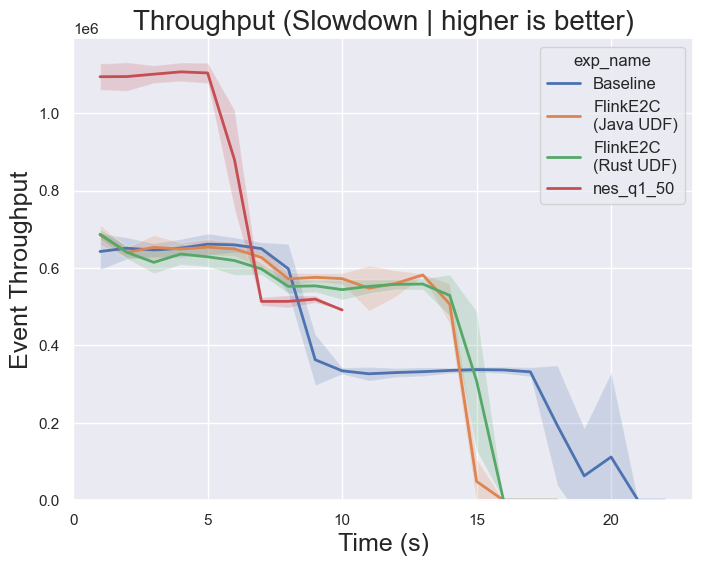

[{'path': 'plot_data_paper/scpu50_line_ci_flink_q1i10.csv',
  'exp_name': 'Baseline',
  'label_tex': 'Baseline',
  'marker_path': None},
 {'path': 'plot_data_paper/scpu50_line_ci_flinke2c_judf_q1i10.csv',
  'exp_name': 'FlinkE2C\n(Java UDF)',
  'label_tex': 'FlinkE2C\\\\(Java UDF)',
  'marker_path': None},
 {'path': 'plot_data_paper/scpu50_line_ci_flinke2c_rudf_q1i10.csv',
  'exp_name': 'FlinkE2C\n(Rust UDF)',
  'label_tex': 'FlinkE2C\\\\(Rust UDF)',
  'marker_path': None},
 {'path': 'plot_data_paper/scpu50_line_ci_nes_q1_50.csv',
  'exp_name': 'nes_q1_50',
  'label_tex': 'nes\\\\_q1\\\\_50',
  'marker_path': None}]

In [30]:
data = process_experiments_nebula(
    path="data/scpu50",
    names=["flink_q1i10", "flinke2c_rudf_q1i10", "flinke2c_judf_q1i10", "nes_q1_50"],
    allow_sink_only=True,
)
event_data = prepare_nebula_event_throughput_mean_ci_data(data, ci=0.95)

event_throughput_mean_ci_line_plot(
    event_data,
    x_name="Time (s)",
    title="Throughput (Slowdown | higher is better)",
    hue="exp_name",
)

# plt.savefig("figs/filter_update.pdf")
plt.show()

gen_event_line_ci_data(
    event_data,
    "scpu50_line_ci",
    output_suffix="paper",
)

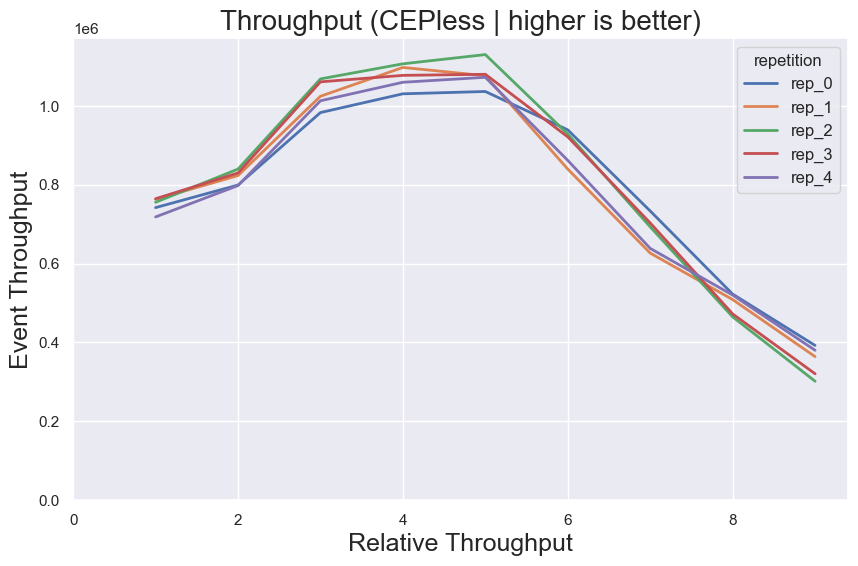

In [ ]:
data = process_experiments_nebula(path="data", names=["flink_q1f"])
event_data = prepare_nebula_event_throughput_data(data, smooth_window=5)

event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (CEPless | higher is better)")
# plt.savefig("figs/flink_cepless_bottom_up.pdf")
plt.show()
event_df = prepare_nebula_event_throughput_data(data, smooth_window=5)
line_meta = gen_event_line_data(event_df, "flink_cepless_bottom_up", output_suffix="paper", use_smoothed=True)